In [1]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

# 1. Зашумить изображение при помощи шума гаусса, постоянного шума.

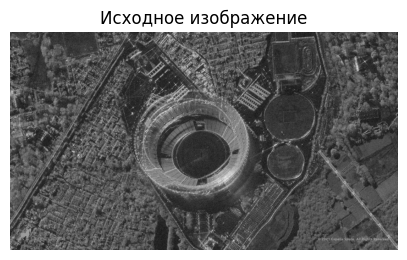

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5,4))
plt.imshow(image_gray, cmap="gray")
plt.title("Исходное изображение")
plt.axis("off")
plt.show()

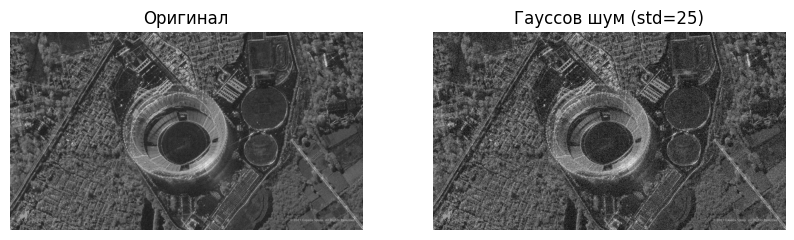

In [3]:
np.random.seed(42)

mean = 0
stddev = 25 
noise_gauss = np.random.normal(mean, stddev, image_gray.shape).astype(np.float32)

image_noise_gauss = image_gray.astype(np.float32) + noise_gauss
image_noise_gauss = np.clip(image_noise_gauss, 0, 255).astype(np.uint8)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image_gray, cmap="gray"); plt.title("Оригинал"); plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(image_noise_gauss, cmap="gray"); plt.title(f"Гауссов шум (std={stddev})"); plt.axis("off")
plt.show()

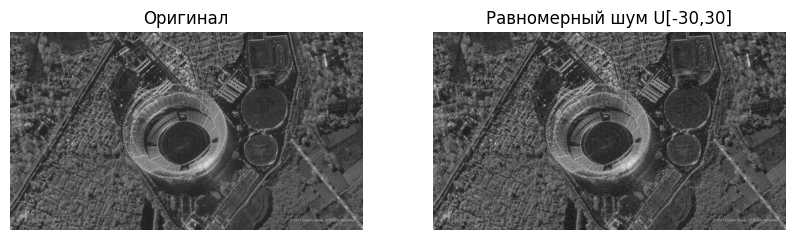

In [4]:
np.random.seed(42)

a = -30
b = 30
noise_uniform = np.random.uniform(a, b, image_gray.shape).astype(np.float32)

image_noise_uniform = image_gray.astype(np.float32) + noise_uniform
image_noise_uniform = np.clip(image_noise_uniform, 0, 255).astype(np.uint8)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image_gray, cmap="gray"); plt.title("Оригинал"); plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(image_noise_uniform, cmap="gray"); plt.title(f"Равномерный шум U[{a},{b}]"); plt.axis("off")
plt.show()


# 2. Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

In [5]:
def eval_and_print(ref, img, name):
    m = mean_squared_error(ref, img)
    s = structural_similarity(ref, img)
    print(f"{name:25s} | MSE={m:10.2f} | SSIM={s:.4f}")
    return m, s

def test_filters(noisy, label):
    print("\n" + "="*60)
    print(f"тест фильтров: {label}")
    print("="*60)

    eval_and_print(image_gray, noisy, "Noisy")

    results = []

    for k in [3, 5, 7]:
        out = cv2.medianBlur(noisy, k)
        m, s = eval_and_print(image_gray, out, f"Median k={k}")
        results.append((s, -m, f"Median k={k}", out))

    for k in [3, 5, 7]:
        out = cv2.GaussianBlur(noisy, (k, k), 0)
        m, s = eval_and_print(image_gray, out, f"Gaussian k={k}")
        results.append((s, -m, f"Gaussian k={k}", out))

    for d, sc, ss in [(5, 50, 50), (9, 75, 75), (9, 150, 150)]:
        out = cv2.bilateralFilter(noisy, d=d, sigmaColor=sc, sigmaSpace=ss)
        m, s = eval_and_print(image_gray, out, f"Bilateral d={d} sc={sc} ss={ss}")
        results.append((s, -m, f"Bilateral d={d} sc={sc} ss={ss}", out))

    for h in [5, 10, 15, 20]:
        out = cv2.fastNlMeansDenoising(noisy, h=h, templateWindowSize=7, searchWindowSize=21)
        m, s = eval_and_print(image_gray, out, f"NLM h={h}")
        results.append((s, -m, f"NLM h={h}", out))

    results.sort(reverse=True)
    best = results[0]
    best_name, best_img = best[2], best[3]

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(noisy, cmap="gray"); plt.title(f"{label}\n(noisy)"); plt.axis("off")
    plt.subplot(1,3,2)
    plt.imshow(best_img, cmap="gray"); plt.title(f"BEST: {best_name}"); plt.axis("off")
    plt.subplot(1,3,3)
    plt.imshow(image_gray, cmap="gray"); plt.title("Оригинал"); plt.axis("off")
    plt.show()

    print(f"\nлучший  '{label}': {best_name}")
    return best_name



тест фильтров: Gaussian noise std=25
Noisy                     | MSE=    610.70 | SSIM=0.4806
Median k=3                | MSE=    211.28 | SSIM=0.6357
Median k=5                | MSE=    240.80 | SSIM=0.5603
Median k=7                | MSE=    286.55 | SSIM=0.4815
Gaussian k=3              | MSE=    150.25 | SSIM=0.7234
Gaussian k=5              | MSE=    156.69 | SSIM=0.7057
Gaussian k=7              | MSE=    188.86 | SSIM=0.6475
Bilateral d=5 sc=50 ss=50 | MSE=    163.18 | SSIM=0.7024
Bilateral d=9 sc=75 ss=75 | MSE=    201.56 | SSIM=0.6128
Bilateral d=9 sc=150 ss=150 | MSE=    252.96 | SSIM=0.5280
NLM h=5                   | MSE=    610.70 | SSIM=0.4806
NLM h=10                  | MSE=    610.61 | SSIM=0.4806
NLM h=15                  | MSE=    420.63 | SSIM=0.5587
NLM h=20                  | MSE=    182.01 | SSIM=0.6653


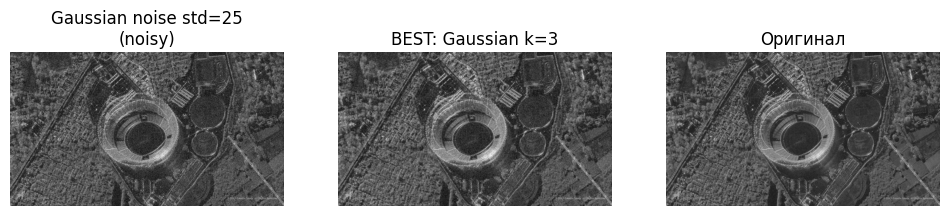


лучший  'Gaussian noise std=25': Gaussian k=3

тест фильтров: Uniform noise U[-30,30]
Noisy                     | MSE=    299.66 | SSIM=0.6294
Median k=3                | MSE=    171.29 | SSIM=0.6803
Median k=5                | MSE=    226.10 | SSIM=0.5768
Median k=7                | MSE=    278.59 | SSIM=0.4898
Gaussian k=3              | MSE=    105.96 | SSIM=0.7929
Gaussian k=5              | MSE=    132.79 | SSIM=0.7465
Gaussian k=7              | MSE=    175.62 | SSIM=0.6689
Bilateral d=5 sc=50 ss=50 | MSE=    113.74 | SSIM=0.7670
Bilateral d=9 sc=75 ss=75 | MSE=    199.86 | SSIM=0.6034
Bilateral d=9 sc=150 ss=150 | MSE=    251.40 | SSIM=0.5258
NLM h=5                   | MSE=    299.66 | SSIM=0.6294
NLM h=10                  | MSE=    269.93 | SSIM=0.6514
NLM h=15                  | MSE=    126.32 | SSIM=0.7472
NLM h=20                  | MSE=    159.20 | SSIM=0.6369


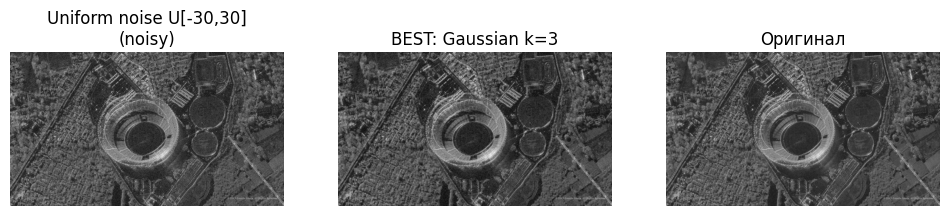


лучший  'Uniform noise U[-30,30]': Gaussian k=3

ИТОГ:
Лучший для гауссова шума   : Gaussian k=3
Лучший для равномерного шума: Gaussian k=3


In [6]:
best_for_gauss = test_filters(image_noise_gauss, f"Gaussian noise std={stddev}")
best_for_uniform = test_filters(image_noise_uniform, f"Uniform noise U[{a},{b}]")

print("\nИТОГ:")
print("Лучший для гауссова шума   :", best_for_gauss)
print("Лучший для равномерного шума:", best_for_uniform)